# Figure 01 final source rebuild

Run top-to-bottom. This notebook rebuilds the computational panels for Figure 1 from the before/after compensation H5AD files and the HuBMAP expert annotations.

Panel A is a BioRender workflow and is not reproduced here. Panels B–F are generated below. Shared cell-type matching and labeling are calculated once and reused for Panels C–F.


## 1. Configure source inputs and analysis settings

The segmentation H5AD files are paired before and after compensation. HuBMAP expert cell-type annotations are used as the reference for Panels C–F.


In [1]:
# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from matplotlib.lines import Line2D
from scipy.stats import ttest_rel
from sklearn.metrics import f1_score
from sklearn.neighbors import NearestNeighbors


In [2]:
# ============================================================
# FILE LOCATIONS
# ============================================================

BASE_DIR = Path(
    "/mnt/jwh83-data/Confetti/output/Redsea/Clustering"
)

HUBMAP_FILE = Path(
    "/mnt/jwh83-data/Confetti/output/"
    "20260130_HuBMAP_Yang_annotate_with_area.h5ad"
)

FILES = {
    "Mesmer": {
        "before": "mesmer_beforeREDSEA_leiden.h5ad",
        "after": "mesmer_afterREDSEA_leiden.h5ad",
    },
    "Cellpose Cyto3": {
        "before": "cellpose_cyto3_beforeREDSEA_leiden.h5ad",
        "after": "cellpose_cyto3_afterREDSEA_leiden.h5ad",
    },
    "CellposeSAM": {
        "before": "cellposeSAM_beforeREDSEA_leiden.h5ad",
        "after": "cellposeSAM_afterREDSEA_leiden.h5ad",
    },
    "CellSAM": {
        "before": "cellSAM_beforeREDSEA_leiden.h5ad",
        "after": "cellSAM_afterREDSEA_leiden.h5ad",
    },
    "InstanSeg": {
        "before": "instanseg_beforeREDSEA_leiden.h5ad",
        "after": "instanseg_afterREDSEA_leiden.h5ad",
    },
    "MicroSAM": {
        "before": "microSAM_beforeREDSEA_leiden.h5ad",
        "after": "microSAM_afterREDSEA_leiden.h5ad",
    },
}

ALGORITHM_ORDER = list(FILES.keys())

FOCUS_FILES = {}
for algorithm, conditions in FILES.items():
    FOCUS_FILES[f"{algorithm} - Before REDSEA"] = conditions["before"]
    FOCUS_FILES[f"{algorithm} - After REDSEA"] = conditions["after"]

VOLCANO_ALGORITHMS = [
    "Mesmer",
    "CellposeSAM",
    "Cellpose Cyto3",
]

VOLCANO_TITLES = {
    "Mesmer": "Mesmer",
    "CellposeSAM": "CellposeSAM",
    "Cellpose Cyto3": "CellposeV3",
}


In [3]:
# ============================================================
# ANALYSIS SETTINGS
# ============================================================

REGION_COL = "slide_name"
GROUPBY = "leiden"
USE_REP = "X_pca"

MAX_NN_DISTANCE = 10
SWAP_HUBMAP_XY = True

HUBMAP_CELLTYPE_COL = "cell_type_update"
HUBMAP_SLIDE_COL = "sample_ID"
SEGMENTATION_SLIDE_COL = "slide_name"
LEIDEN_COL = "leiden"
HUBMAP_X_COL = "x"
HUBMAP_Y_COL = "y"
SEGMENTATION_X_COL = "x_centroid"
SEGMENTATION_Y_COL = "y_centroid"

ONLY_PRESENT_CELL_TYPES = True


In [4]:
# ============================================================
# COLORS
# ============================================================

DOT_COLOR = "#222222"

METHOD_BASE_COLORS = {
    "Mesmer": "#4E79A7",
    "Cellpose Cyto3": "#F28E2B",
    "CellposeSAM": "#59A14F",
    "CellSAM": "#E15759",
    "InstanSeg": "#B07AA1",
    "MicroSAM": "#76B7B2",
}

CELL_TYPE_COLORS = {
    "Epithelial": "#1f77b4",
    "Stromal": "#aec7e8",
    "Smooth muscle": "#ff7f0e",
    "Plasma": "#ffbb78",
    "M2 Macrophage": "#2ca02c",
    "CD8+ T": "#98df8a",
    "Nerve": "#d62728",
    "Noise": "#ff9896",
    "CD49a+ Smooth muscle": "#9467bd",
    "CD66+ Epithelial": "#c5b0d5",
    "TA": "#8c564b",
    "CD4+ T": "#c49c94",
    "CD36 low Endothelial": "#e377c2",
    "Goblet": "#f7b6d2",
    "CD36 high Endothelial": "#7f7f7f",
    "MUC1+ Epithelial": "#c7c7c7",
    "ITLN+ Epithelial": "#bcbd22",
    "DC": "#dbdb8d",
    "PDPN+ Stromal": "#17becf",
    "B": "#9edae5",
    "Cycling TA": "#e65c5c",
    "M1 Macrophage": "#e6c35c",
    "Paneth": "#a1e65c",
    "Neuroendocrine": "#5ce67e",
    "Neutrophil": "#5ce6e6",
    "ICC": "#5c7ee6",
    "CD57+ Epithelial": "#a15ce6",
    "NK": "#e65cc3",
}


## 2. Panel B analysis

Panel B shows the distribution of slide-level changes in Silhouette score after compensation. Silhouette score is calculated independently within each shared slide using the Leiden labels in PCA space, then the after-minus-before change is calculated for each slide.


In [5]:
# ============================================================
# PANEL B: SILHOUETTE SCORE CALCULATION
# ============================================================

def read_cluster_file(filename):
    filepath = BASE_DIR / filename

    if not filepath.exists():
        raise FileNotFoundError(
            f"File not found: {filepath}"
        )

    return sc.read_h5ad(filepath)


def compute_silhouette_score(adata, label):
    if USE_REP not in adata.obsm:
        print(f"[{label}] skipped: {USE_REP} not found")
        return np.nan

    if GROUPBY not in adata.obs:
        print(f"[{label}] skipped: {GROUPBY} not found")
        return np.nan

    X = np.asarray(
        adata.obsm[USE_REP],
        dtype=np.float32,
    )

    labels = (
        adata.obs[GROUPBY]
        .astype(str)
        .to_numpy()
    )

    valid = np.isfinite(X).all(axis=1)
    X = X[valid]
    labels = labels[valid]

    n_cells = X.shape[0]
    n_clusters = np.unique(labels).size

    if n_cells < 3 or n_clusters < 2 or n_clusters >= n_cells:
        print(
            f"[{label}] skipped: "
            f"{n_cells:,} cells and {n_clusters} clusters"
        )
        return np.nan

    try:
        import cupy as cp
        import cuml.metrics as cuml_metrics

        value = float(
            cuml_metrics.silhouette_score(
                cp.asarray(X),
                labels,
            )
        )
    except Exception:
        from sklearn.metrics import silhouette_score

        value = float(
            silhouette_score(
                X,
                labels,
            )
        )

    print(
        f"[{label}] {n_cells:,} cells | "
        f"{n_clusters} clusters | "
        f"Silhouette: {value:.4f}"
    )

    return value


def compute_all_slide_silhouette_changes():
    rows = []

    for method, files in FILES.items():
        print("\n" + "=" * 70)
        print("=" * 70)

        adata_before = read_cluster_file(files["before"])
        adata_after = read_cluster_file(files["after"])

        if REGION_COL not in adata_before.obs:
            raise KeyError(
                f"{REGION_COL!r} was not found in {files['before']}"
            )

        if REGION_COL not in adata_after.obs:
            raise KeyError(
                f"{REGION_COL!r} was not found in {files['after']}"
            )

        before_regions = set(
            adata_before.obs[REGION_COL].astype(str)
        )
        after_regions = set(
            adata_after.obs[REGION_COL].astype(str)
        )

        shared_regions = sorted(
            before_regions & after_regions
        )

        print(f"Shared regions: {len(shared_regions)}")

        for region in shared_regions:
            before_mask = (
                adata_before.obs[REGION_COL].astype(str)
                == region
            )
            after_mask = (
                adata_after.obs[REGION_COL].astype(str)
                == region
            )

            before_value = compute_silhouette_score(
                adata_before[before_mask],
                f"{method} | {region} | before Compensation",
            )

            after_value = compute_silhouette_score(
                adata_after[after_mask],
                f"{method} | {region} | after Compensation",
            )

            delta_value = (
                after_value - before_value
                if np.isfinite(before_value) and np.isfinite(after_value)
                else np.nan
            )

            rows.append(
                {
                    "method": method,
                    "region": region,
                    "silhouette_before": before_value,
                    "silhouette_after": after_value,
                    "delta_silhouette": delta_value,
                }
            )

        del adata_before
        del adata_after

    return pd.DataFrame(rows)


In [6]:
# ============================================================
# RUN PANEL B CALCULATION ONCE
# ============================================================

silhouette_change_df = (
    compute_all_slide_silhouette_changes()
)


/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Shared regions: 8
[Mesmer | B004-A-004 | before Compensation] 15,012 cells | 34 clusters | Silhouette: 0.0345
[Mesmer | B004-A-004 | after Compensation] 14,925 cells | 33 clusters | Silhouette: 0.0054
[Mesmer | B004-A-008 | before Compensation] 21,347 cells | 38 clusters | Silhouette: 0.0052
[Mesmer | B004-A-008 | after Compensation] 21,308 cells | 35 clusters | Silhouette: 0.0025
[Mesmer | B004-A-104 | before Compensation] 25,037 cells | 35 clusters | Silhouette: -0.0004
[Mesmer | B004-A-104 | after Compensation] 24,907 cells | 34 clusters | Silhouette: -0.0209
[Mesmer | B004-A-204 | before Compensation] 13,459 cells | 35 clusters | Silhouette: 0.0065
[Mesmer | B004-A-204 | after Compensation] 13,413 cells | 35 clusters | Silhouette: -0.0261
[Mesmer | B004-A-304 | before Compensation] 14,470 cells | 36 clusters | Silhouette: -0.0227
[Mesmer | B004-A-304 | after Compensation] 14,398 cells | 34 clusters | Silhouette: -0.0104
[Mesmer | B004-A-404 | before Compensation] 24,298 cells | 34 

/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Shared regions: 8
[Cellpose Cyto3 | B004-A-004 | before Compensation] 10,065 cells | 31 clusters | Silhouette: 0.0449
[Cellpose Cyto3 | B004-A-004 | after Compensation] 9,967 cells | 29 clusters | Silhouette: 0.0176
[Cellpose Cyto3 | B004-A-008 | before Compensation] 20,455 cells | 34 clusters | Silhouette: -0.0098
[Cellpose Cyto3 | B004-A-008 | after Compensation] 20,400 cells | 30 clusters | Silhouette: 0.0118
[Cellpose Cyto3 | B004-A-104 | before Compensation] 23,479 cells | 31 clusters | Silhouette: -0.0007
[Cellpose Cyto3 | B004-A-104 | after Compensation] 23,345 cells | 30 clusters | Silhouette: -0.0323
[Cellpose Cyto3 | B004-A-204 | before Compensation] 12,656 cells | 32 clusters | Silhouette: -0.0473
[Cellpose Cyto3 | B004-A-204 | after Compensation] 12,570 cells | 29 clusters | Silhouette: -0.0832
[Cellpose Cyto3 | B004-A-304 | before Compensation] 12,120 cells | 33 clusters | Silhouette: -0.0723
[Cellpose Cyto3 | B004-A-304 | after Compensation] 12,094 cells | 31 clusters | S

/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


...

Shared regions: 8
[CellSAM | B004-A-004 | before Compensation] 16,144 cells | 34 clusters | Silhouette: 0.0125
[CellSAM | B004-A-004 | after Compensation] 16,087 cells | 44 clusters | Silhouette: -0.0322
[CellSAM | B004-A-008 | before Compensation] 25,903 cells | 39 clusters | Silhouette: -0.0041
[CellSAM | B004-A-008 | after Compensation] 25,829 cells | 50 clusters | Silhouette: -0.0411
[CellSAM | B004-A-104 | before Compensation] 30,796 cells | 35 clusters | Silhouette: 0.0027
[CellSAM | B004-A-104 | after Compensation] 30,666 cells | 47 clusters | Silhouette: -0.0285
[CellSAM | B004-A-204 | before Compensation] 17,270 cells | 36 clusters | Silhouette: -0.0325
[CellSAM | B004-A-204 | after Compensation] 17,200 cells | 49 clusters | Silhouette: -0.0802
[CellSAM | B004-A-304 | before Compensation] 16,396 cells | 37 clusters | Silhouette: -0.0046
[CellSAM | B004-A-304 | after Compensation] 16,171 cells | 49 clusters | Silhouette: -0.0577
[CellSAM | B004-A-404 | before Compensation] 29,3

/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Shared regions: 8
[InstanSeg | B004-A-004 | before Compensation] 14,625 cells | 34 clusters | Silhouette: 0.0063
[InstanSeg | B004-A-004 | after Compensation] 14,455 cells | 34 clusters | Silhouette: -0.0202
[InstanSeg | B004-A-008 | before Compensation] 26,862 cells | 39 clusters | Silhouette: -0.0084
[InstanSeg | B004-A-008 | after Compensation] 26,599 cells | 36 clusters | Silhouette: -0.0367
[InstanSeg | B004-A-104 | before Compensation] 33,030 cells | 37 clusters | Silhouette: -0.0771
[InstanSeg | B004-A-104 | after Compensation] 32,497 cells | 34 clusters | Silhouette: -0.0391
[InstanSeg | B004-A-204 | before Compensation] 17,183 cells | 36 clusters | Silhouette: -0.0461
[InstanSeg | B004-A-204 | after Compensation] 17,110 cells | 34 clusters | Silhouette: -0.0727
[InstanSeg | B004-A-304 | before Compensation] 15,503 cells | 37 clusters | Silhouette: -0.0472
[InstanSeg | B004-A-304 | after Compensation] 15,386 cells | 35 clusters | Silhouette: -0.0442
[InstanSeg | B004-A-404 | be

/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Shared regions: 8
[MicroSAM | B004-A-004 | before Compensation] 10,645 cells | 32 clusters | Silhouette: 0.0233
[MicroSAM | B004-A-004 | after Compensation] 10,648 cells | 36 clusters | Silhouette: -0.0218
[MicroSAM | B004-A-008 | before Compensation] 27,199 cells | 35 clusters | Silhouette: -0.0135
[MicroSAM | B004-A-008 | after Compensation] 27,147 cells | 37 clusters | Silhouette: -0.0314
[MicroSAM | B004-A-104 | before Compensation] 30,485 cells | 33 clusters | Silhouette: 0.0050
[MicroSAM | B004-A-104 | after Compensation] 30,510 cells | 36 clusters | Silhouette: -0.0592
[MicroSAM | B004-A-204 | before Compensation] 18,388 cells | 35 clusters | Silhouette: -0.0663
[MicroSAM | B004-A-204 | after Compensation] 18,424 cells | 37 clusters | Silhouette: -0.0658
[MicroSAM | B004-A-304 | before Compensation] 16,594 cells | 34 clusters | Silhouette: -0.0624
[MicroSAM | B004-A-304 | after Compensation] 16,568 cells | 37 clusters | Silhouette: -0.0542
[MicroSAM | B004-A-404 | before Compens

## 3. Shared HuBMAP matching and cluster labeling for Panels C–F

The following analysis is performed once and reused for the F1 box plot and all three volcano plots. Each segmentation cell is matched to its nearest HuBMAP reference cell within the same slide, using a maximum distance of 10 pixels. Leiden clusters are then assigned the dominant matched HuBMAP cell type.


In [7]:
# ============================================================
# NEAREST-NEIGHBOR MATCHING
# ============================================================

def build_nearest_neighbor_celltype_matches(
    focus_files=FOCUS_FILES,
    hubmap_file=HUBMAP_FILE,
    hubmap_celltype_col=HUBMAP_CELLTYPE_COL,
    hubmap_slide_col=HUBMAP_SLIDE_COL,
    segmentation_slide_col=SEGMENTATION_SLIDE_COL,
    leiden_col=LEIDEN_COL,
    hubmap_x_col=HUBMAP_X_COL,
    hubmap_y_col=HUBMAP_Y_COL,
    segmentation_x_col=SEGMENTATION_X_COL,
    segmentation_y_col=SEGMENTATION_Y_COL,
    max_nn_distance=MAX_NN_DISTANCE,
    swap_hubmap_xy=SWAP_HUBMAP_XY,
):
    adata_hub = sc.read_h5ad(hubmap_file)

    required_hub_cols = [
        hubmap_celltype_col,
        hubmap_slide_col,
        hubmap_x_col,
        hubmap_y_col,
    ]

    missing_hub_cols = [
        column
        for column in required_hub_cols
        if column not in adata_hub.obs.columns
    ]

    if missing_hub_cols:
        raise ValueError(
            "HuBMAP file is missing obs columns: "
            f"{missing_hub_cols}"
        )

    hub_obs = adata_hub.obs[required_hub_cols].copy()

    hub_obs[hubmap_x_col] = pd.to_numeric(
        hub_obs[hubmap_x_col],
        errors="coerce",
    )
    hub_obs[hubmap_y_col] = pd.to_numeric(
        hub_obs[hubmap_y_col],
        errors="coerce",
    )
    hub_obs[hubmap_slide_col] = (
        hub_obs[hubmap_slide_col]
        .astype("object")
        .fillna("Unknown")
        .astype(str)
    )
    hub_obs[hubmap_celltype_col] = (
        hub_obs[hubmap_celltype_col]
        .astype("object")
        .fillna("Unknown")
        .astype(str)
    )

    if swap_hubmap_xy:
        hub_obs["hubmap_x_used"] = hub_obs[hubmap_y_col]
        hub_obs["hubmap_y_used"] = hub_obs[hubmap_x_col]
    else:
        hub_obs["hubmap_x_used"] = hub_obs[hubmap_x_col]
        hub_obs["hubmap_y_used"] = hub_obs[hubmap_y_col]

    hub_obs = hub_obs.dropna(
        subset=["hubmap_x_used", "hubmap_y_used"]
    ).copy()

    matched_rows = []

    for method, filename in focus_files.items():
        file_path = BASE_DIR / filename

        if not file_path.exists():
            raise FileNotFoundError(
                f"File not found for {method}: {file_path}"
            )

        adata = sc.read_h5ad(file_path)

        required_segmentation_cols = [
            segmentation_x_col,
            segmentation_y_col,
            segmentation_slide_col,
            leiden_col,
        ]

        missing_segmentation_cols = [
            column
            for column in required_segmentation_cols
            if column not in adata.obs.columns
        ]

        if missing_segmentation_cols:
            raise ValueError(
                f"{method} is missing obs columns: "
                f"{missing_segmentation_cols}"
            )

        segmentation_obs = adata.obs[
            required_segmentation_cols
        ].copy()

        segmentation_obs[segmentation_x_col] = pd.to_numeric(
            segmentation_obs[segmentation_x_col],
            errors="coerce",
        )
        segmentation_obs[segmentation_y_col] = pd.to_numeric(
            segmentation_obs[segmentation_y_col],
            errors="coerce",
        )
        segmentation_obs[segmentation_slide_col] = (
            segmentation_obs[segmentation_slide_col]
            .astype("object")
            .fillna("Unknown")
            .astype(str)
        )
        segmentation_obs[leiden_col] = (
            segmentation_obs[leiden_col]
            .astype("object")
            .fillna("Unknown")
            .astype(str)
        )

        segmentation_obs = segmentation_obs.dropna(
            subset=[segmentation_x_col, segmentation_y_col]
        ).copy()

        for slide in sorted(
            segmentation_obs[segmentation_slide_col].unique()
        ):
            segmentation_slide = segmentation_obs[
                segmentation_obs[segmentation_slide_col] == slide
            ].copy()

            hubmap_slide = hub_obs[
                hub_obs[hubmap_slide_col] == slide
            ].copy()

            if hubmap_slide.empty:
                continue

            nearest_neighbors = NearestNeighbors(n_neighbors=1)
            nearest_neighbors.fit(
                hubmap_slide[
                    ["hubmap_x_used", "hubmap_y_used"]
                ].to_numpy()
            )

            distances, indices = nearest_neighbors.kneighbors(
                segmentation_slide[
                    [segmentation_x_col, segmentation_y_col]
                ].to_numpy()
            )

            distances = distances[:, 0]
            indices = indices[:, 0]

            matched_hubmap_cells = (
                hubmap_slide.iloc[indices].copy()
            )

            slide_matches = pd.DataFrame(
                {
                    "method": method,
                    "file": filename,
                    "slide": slide,
                    "seg_cell": segmentation_slide.index.to_numpy(),
                    "seg_leiden": segmentation_slide[leiden_col].to_numpy(),
                    "true_cell_type": matched_hubmap_cells[
                        hubmap_celltype_col
                    ].to_numpy(),
                    "nn_distance": distances,
                    "within_radius": distances <= max_nn_distance,
                }
            )

            matched_rows.append(slide_matches)

        del adata

    if not matched_rows:
        raise ValueError(
            "No segmentation cells could be matched to HuBMAP."
        )

    matched_cells_df = pd.concat(
        matched_rows,
        ignore_index=True,
    )

    matched_cells_df["true_cell_type"] = (
        matched_cells_df["true_cell_type"]
        .astype("object")
        .fillna("Unknown")
        .astype(str)
    )
    matched_cells_df["seg_leiden"] = (
        matched_cells_df["seg_leiden"].astype(str)
    )
    matched_cells_df["slide"] = (
        matched_cells_df["slide"].astype(str)
    )

    return matched_cells_df


In [8]:
# ============================================================
# DOMINANT CELL TYPE PER LEIDEN CLUSTER
# ============================================================

def calculate_dominant_cell_type_per_cluster(
    matched_cells_df,
):
    scored_cells_df = matched_cells_df[
        matched_cells_df["within_radius"]
    ].copy()

    if scored_cells_df.empty:
        raise ValueError(
            "No segmentation cells were within the matching distance."
        )

    cluster_celltype_counts_df = (
        scored_cells_df
        .groupby(
            [
                "method",
                "file",
                "seg_leiden",
                "true_cell_type",
            ],
            as_index=False,
        )
        .agg(
            cell_count=("seg_cell", "size"),
        )
    )

    cluster_totals_df = (
        cluster_celltype_counts_df
        .groupby(
            ["method", "file", "seg_leiden"],
            as_index=False,
        )
        .agg(
            total_matched_cells=("cell_count", "sum"),
        )
    )

    cluster_celltype_counts_df = (
        cluster_celltype_counts_df.merge(
            cluster_totals_df,
            on=["method", "file", "seg_leiden"],
            how="left",
        )
    )

    cluster_celltype_counts_df["cell_type_fraction"] = (
        cluster_celltype_counts_df["cell_count"]
        / cluster_celltype_counts_df["total_matched_cells"]
    )

    cluster_celltype_counts_df = (
        cluster_celltype_counts_df
        .sort_values(
            [
                "method",
                "file",
                "seg_leiden",
                "cell_count",
                "true_cell_type",
            ],
            ascending=[True, True, True, False, True],
        )
        .reset_index(drop=True)
    )

    cluster_celltype_counts_df["cell_type_rank"] = (
        cluster_celltype_counts_df
        .groupby(["method", "file", "seg_leiden"])
        .cumcount()
        + 1
    )

    dominant_cell_types_df = (
        cluster_celltype_counts_df[
            cluster_celltype_counts_df["cell_type_rank"] == 1
        ]
        .rename(
            columns={
                "seg_leiden": "leiden",
                "true_cell_type": "dominant_cell_type",
            }
        )
        [
            [
                "method",
                "file",
                "leiden",
                "dominant_cell_type",
            ]
        ]
        .reset_index(drop=True)
    )

    return dominant_cell_types_df, cluster_celltype_counts_df


def assign_cluster_labels_to_cells(
    matched_cells_df,
    dominant_cell_types_df,
):
    cluster_mapping_df = dominant_cell_types_df[
        ["method", "file", "leiden", "dominant_cell_type"]
    ].copy()

    cluster_mapping_df["method"] = (
        cluster_mapping_df["method"].astype(str)
    )
    cluster_mapping_df["file"] = (
        cluster_mapping_df["file"].astype(str)
    )
    cluster_mapping_df["leiden"] = (
        cluster_mapping_df["leiden"].astype(str)
    )

    labeled_cells_df = matched_cells_df.merge(
        cluster_mapping_df,
        left_on=["method", "file", "seg_leiden"],
        right_on=["method", "file", "leiden"],
        how="left",
    )

    labeled_cells_df = labeled_cells_df.drop(
        columns=["leiden"]
    )
    labeled_cells_df = labeled_cells_df.rename(
        columns={
            "dominant_cell_type": "predicted_cell_type"
        }
    )

    labeled_cells_df["predicted_cell_type"] = (
        labeled_cells_df["predicted_cell_type"]
        .astype("object")
        .fillna("Unmapped")
        .astype(str)
    )

    return labeled_cells_df


In [9]:
# ============================================================
# RUN SHARED CELL-TYPE MATCHING AND LABELING ONCE
# ============================================================

celltype_matched_cells_df = (
    build_nearest_neighbor_celltype_matches()
)

(
    dominant_cell_types_df,
    cluster_celltype_counts_df,
) = calculate_dominant_cell_type_per_cluster(
    matched_cells_df=celltype_matched_cells_df
)

celltype_labeled_cells_df = (
    assign_cluster_labels_to_cells(
        matched_cells_df=celltype_matched_cells_df,
        dominant_cell_types_df=dominant_cell_types_df,
    )
)


/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell

## 4. Panel C analysis

Panel C compares cell-type F1 scores before and after compensation. Each Leiden cluster receives its dominant HuBMAP cell-type label, and F1 is then calculated one-versus-rest for each cell type using all scored cells for each method and condition.


In [10]:
# ============================================================
# PANEL C: CELL-TYPE F1 SCORES
# ============================================================

def calculate_celltype_f1_scores(
    labeled_cells_df,
):
    scored_cells_df = labeled_cells_df[
        labeled_cells_df["within_radius"]
        & (
            labeled_cells_df["predicted_cell_type"]
            != "Unmapped"
        )
    ].copy()

    if scored_cells_df.empty:
        raise ValueError(
            "No labeled cells were available for scoring."
        )

    all_cell_types = sorted(
        set(scored_cells_df["true_cell_type"].astype(str))
        | set(scored_cells_df["predicted_cell_type"].astype(str))
    )

    metric_rows = []

    for method in FOCUS_FILES:
        method_cells = scored_cells_df[
            scored_cells_df["method"] == method
        ].copy()

        if method_cells.empty:
            continue

        true_multiclass = (
            method_cells["true_cell_type"]
            .astype(str)
            .to_numpy()
        )
        predicted_multiclass = (
            method_cells["predicted_cell_type"]
            .astype(str)
            .to_numpy()
        )

        for cell_type in all_cell_types:
            true_binary = true_multiclass == cell_type
            predicted_binary = predicted_multiclass == cell_type

            metric_rows.append(
                {
                    "method": method,
                    "cell_type": cell_type,
                    "true_cell_count": int(true_binary.sum()),
                    "predicted_cell_count": int(predicted_binary.sum()),
                    "f1": float(
                        f1_score(
                            true_binary,
                            predicted_binary,
                            zero_division=0,
                        )
                    ),
                }
            )

    celltype_f1_df = pd.DataFrame(metric_rows)

    celltype_f1_df["algorithm"] = (
        celltype_f1_df["method"]
        .str.replace(" - Before REDSEA", "", regex=False)
        .str.replace(" - After REDSEA", "", regex=False)
    )

    celltype_f1_df["condition"] = np.where(
        celltype_f1_df["method"].str.contains(
            "Before REDSEA",
            regex=False,
        ),
        "before",
        "after",
    )

    return celltype_f1_df


def calculate_before_after_f1_change(
    celltype_f1_df,
):
    before_df = (
        celltype_f1_df[
            celltype_f1_df["condition"] == "before"
        ][
            [
                "algorithm",
                "cell_type",
                "f1",
                "true_cell_count",
                "predicted_cell_count",
            ]
        ]
        .rename(
            columns={
                "f1": "f1_before",
                "true_cell_count": "true_cell_count_before",
                "predicted_cell_count": "predicted_cell_count_before",
            }
        )
    )

    after_df = (
        celltype_f1_df[
            celltype_f1_df["condition"] == "after"
        ][
            [
                "algorithm",
                "cell_type",
                "f1",
                "true_cell_count",
                "predicted_cell_count",
            ]
        ]
        .rename(
            columns={
                "f1": "f1_after",
                "true_cell_count": "true_cell_count_after",
                "predicted_cell_count": "predicted_cell_count_after",
            }
        )
    )

    change_df = before_df.merge(
        after_df,
        on=["algorithm", "cell_type"],
        how="outer",
    )

    numeric_columns = [
        column
        for column in change_df.columns
        if column not in ["algorithm", "cell_type"]
    ]

    change_df[numeric_columns] = (
        change_df[numeric_columns].fillna(0)
    )

    change_df["delta_f1"] = (
        change_df["f1_after"]
        - change_df["f1_before"]
    )

    return change_df


In [11]:
# ============================================================
# RUN PANEL C CALCULATION ONCE
# ============================================================

celltype_f1_df = calculate_celltype_f1_scores(
    labeled_cells_df=celltype_labeled_cells_df
)

celltype_f1_change_df = (
    calculate_before_after_f1_change(
        celltype_f1_df=celltype_f1_df
    )
)


## 5. Panels D–F analysis

Panels D–F evaluate cell-type-specific changes in F1 score across slides for Mesmer, CellposeSAM, and CellposeV3. F1 is calculated separately within each slide. Before and after scores are paired by slide for each cell type, followed by a paired t-test. Bonferroni correction is applied separately within each segmentation algorithm across the valid cell-type tests.


In [12]:
# ============================================================
# PANELS D-F: SLIDE-LEVEL CELL-TYPE F1
# ============================================================

def calculate_binary_f1(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=bool)
    y_pred = np.asarray(y_pred, dtype=bool)

    true_positive = np.sum(y_true & y_pred)
    false_positive = np.sum(~y_true & y_pred)
    false_negative = np.sum(y_true & ~y_pred)

    denominator = (
        (2 * true_positive)
        + false_positive
        + false_negative
    )

    if denominator == 0:
        return 0.0

    return (2 * true_positive) / denominator


def calculate_slide_level_celltype_f1(
    labeled_cells_df,
    algorithms=VOLCANO_ALGORITHMS,
    only_present_cell_types=True,
):
    scored_df = labeled_cells_df[
        labeled_cells_df["within_radius"]
        & (
            labeled_cells_df["predicted_cell_type"]
            != "Unmapped"
        )
    ].copy()

    if scored_df.empty:
        raise ValueError(
            "No labeled cells were available for slide-level scoring."
        )

    scored_df["algorithm"] = (
        scored_df["method"]
        .str.replace(" - Before REDSEA", "", regex=False)
        .str.replace(" - After REDSEA", "", regex=False)
    )

    scored_df["condition"] = np.where(
        scored_df["method"].str.contains(
            "Before REDSEA",
            regex=False,
        ),
        "before",
        "after",
    )

    scored_df["slide"] = scored_df["slide"].astype(str)
    scored_df["true_cell_type"] = (
        scored_df["true_cell_type"].astype(str)
    )
    scored_df["predicted_cell_type"] = (
        scored_df["predicted_cell_type"].astype(str)
    )

    result_rows = []

    for algorithm in algorithms:
        algorithm_df = scored_df[
            scored_df["algorithm"] == algorithm
        ].copy()

        if algorithm_df.empty:
            continue

        cell_types = sorted(
            set(algorithm_df["true_cell_type"].unique())
            | set(algorithm_df["predicted_cell_type"].unique())
        )

        slides = sorted(
            algorithm_df["slide"].unique()
        )

        for condition in ["before", "after"]:
            condition_df = algorithm_df[
                algorithm_df["condition"] == condition
            ].copy()

            for slide in slides:
                slide_df = condition_df[
                    condition_df["slide"] == slide
                ].copy()

                if slide_df.empty:
                    continue

                true_multiclass = (
                    slide_df["true_cell_type"].to_numpy()
                )
                predicted_multiclass = (
                    slide_df["predicted_cell_type"].to_numpy()
                )

                for cell_type in cell_types:
                    y_true = true_multiclass == cell_type
                    y_pred = predicted_multiclass == cell_type

                    true_cell_count = int(y_true.sum())
                    predicted_cell_count = int(y_pred.sum())

                    present = (
                        true_cell_count > 0
                        or predicted_cell_count > 0
                    )

                    if only_present_cell_types and not present:
                        continue

                    result_rows.append(
                        {
                            "algorithm": algorithm,
                            "condition": condition,
                            "slide": slide,
                            "cell_type": cell_type,
                            "true_cell_count": true_cell_count,
                            "predicted_cell_count": predicted_cell_count,
                            "f1": float(
                                calculate_binary_f1(
                                    y_true,
                                    y_pred,
                                )
                            ),
                        }
                    )

    slide_f1_df = pd.DataFrame(result_rows)

    if slide_f1_df.empty:
        raise ValueError(
            "No slide-level F1 scores could be calculated."
        )

    return slide_f1_df


In [13]:
# ============================================================
# PAIRED T-TEST ACROSS SLIDES
# ============================================================

def calculate_slide_level_paired_t_tests(
    slide_f1_df,
    algorithms=VOLCANO_ALGORITHMS,
    only_present_cell_types=True,
):
    result_rows = []

    for algorithm in algorithms:
        algorithm_df = slide_f1_df[
            slide_f1_df["algorithm"] == algorithm
        ].copy()

        if algorithm_df.empty:
            continue

        algorithm_rows = []

        for cell_type in sorted(
            algorithm_df["cell_type"].astype(str).unique()
        ):
            cell_df = algorithm_df[
                algorithm_df["cell_type"] == cell_type
            ].copy()

            before_df = (
                cell_df[cell_df["condition"] == "before"]
                [
                    [
                        "slide",
                        "f1",
                        "true_cell_count",
                        "predicted_cell_count",
                    ]
                ]
                .rename(
                    columns={
                        "f1": "f1_before",
                        "true_cell_count": "true_count_before",
                        "predicted_cell_count": "predicted_count_before",
                    }
                )
            )

            after_df = (
                cell_df[cell_df["condition"] == "after"]
                [
                    [
                        "slide",
                        "f1",
                        "true_cell_count",
                        "predicted_cell_count",
                    ]
                ]
                .rename(
                    columns={
                        "f1": "f1_after",
                        "true_cell_count": "true_count_after",
                        "predicted_cell_count": "predicted_count_after",
                    }
                )
            )

            paired_df = before_df.merge(
                after_df,
                on="slide",
                how="inner",
            )

            if paired_df.empty:
                continue

            if only_present_cell_types:
                present_mask = (
                    (paired_df["true_count_before"] > 0)
                    | (paired_df["true_count_after"] > 0)
                    | (paired_df["predicted_count_before"] > 0)
                    | (paired_df["predicted_count_after"] > 0)
                )
                paired_df = paired_df[present_mask].copy()

            n_paired_slides = len(paired_df)

            if n_paired_slides == 0:
                continue

            before_values = paired_df["f1_before"].to_numpy(dtype=float)
            after_values = paired_df["f1_after"].to_numpy(dtype=float)
            slide_differences = after_values - before_values

            if n_paired_slides < 2:
                t_statistic = np.nan
                p_value = np.nan
            elif np.allclose(slide_differences, 0):
                t_statistic = 0.0
                p_value = 1.0
            else:
                test_result = ttest_rel(
                    after_values,
                    before_values,
                    nan_policy="omit",
                )
                t_statistic = float(test_result.statistic)
                p_value = float(test_result.pvalue)

            algorithm_rows.append(
                {
                    "algorithm": algorithm,
                    "cell_type": cell_type,
                    "n_paired_slides": n_paired_slides,
                    "mean_f1_before": float(np.mean(before_values)),
                    "mean_f1_after": float(np.mean(after_values)),
                    "delta_f1": float(np.mean(slide_differences)),
                    "median_delta_f1": float(np.median(slide_differences)),
                    "t_statistic": t_statistic,
                    "p_value": p_value,
                }
            )

        if not algorithm_rows:
            continue

        algorithm_result_df = pd.DataFrame(algorithm_rows)
        valid_test_mask = algorithm_result_df["p_value"].notna()
        number_of_cell_types_tested = int(valid_test_mask.sum())

        algorithm_result_df["n_cell_types_tested"] = (
            number_of_cell_types_tested
        )
        algorithm_result_df["adjusted_p_value"] = np.nan

        if number_of_cell_types_tested > 0:
            algorithm_result_df.loc[
                valid_test_mask,
                "adjusted_p_value",
            ] = np.minimum(
                algorithm_result_df.loc[
                    valid_test_mask,
                    "p_value",
                ]
                * number_of_cell_types_tested,
                1.0,
            )

        result_rows.extend(
            algorithm_result_df.to_dict(orient="records")
        )

    significance_df = pd.DataFrame(result_rows)

    if significance_df.empty:
        raise ValueError(
            "No paired t-tests could be calculated."
        )

    significance_df["minus_log10_adjusted_p"] = np.where(
        significance_df["adjusted_p_value"].notna(),
        -np.log10(
            significance_df["adjusted_p_value"].clip(
                lower=np.finfo(float).tiny
            )
        ),
        np.nan,
    )

    return significance_df


In [14]:
# ============================================================
# RUN PANELS D-F CALCULATIONS ONCE
# ============================================================

celltype_slide_f1_df = (
    calculate_slide_level_celltype_f1(
        labeled_cells_df=celltype_labeled_cells_df,
        algorithms=VOLCANO_ALGORITHMS,
        only_present_cell_types=True,
    )
)

celltype_f1_significance_df = (
    calculate_slide_level_paired_t_tests(
        slide_f1_df=celltype_slide_f1_df,
        algorithms=VOLCANO_ALGORITHMS,
        only_present_cell_types=True,
    )
)


## 6. Plot settings

Edit figure dimensions, font sizes, marker sizes, and legend placement here. All calculations above can remain unchanged when only plot appearance is adjusted.


In [15]:
# ============================================================
# PLOT SETTINGS
#
# EDIT ALL FONT SIZES IN THIS SECTION.
# Rerun this cell and the plotting cells after making changes.
# ============================================================

PANEL_B_SETTINGS = {
    "figure_size": (11, 5.5),
    "title_fontsize": 15,
    "axis_label_fontsize": 13,
    "x_tick_fontsize": 13,
    "y_tick_fontsize": 13,
    "legend_fontsize": 13,
    "dot_size": 30,
    "mean_marker_size": 75,
    "dot_alpha": 0.80,
    "zero_linewidth": 0.80,
}

PANEL_C_FONT_SIZES = {
    "title": 22,
    "x_axis_label": 20,
    "y_axis_label": 20,
    "x_tick_labels": 20,
    "y_tick_labels": 20,
    "legend_title": 15,
    "legend_labels": 12,
}

PANEL_C_SETTINGS = {
    "figure_size": (18, 10),
    "box_width": 0.55,
    "dot_size": 55,
    "dot_edge_width": 0.5,
    "dot_alpha": 0.90,
    "jitter_width": 0.16,
    "jitter_seed": 42,
    "title_padding": 14,
    "legend_columns": 1,
    "legend_x_position": 1.02,
    "legend_y_position": 1.00,
    "legend_marker_size": 7,
    "legend_marker_edge_width": 0.5,
    "zero_line_color": "#444441",
    "zero_line_width": 1.0,
    "zero_line_style": "--",
}

VOLCANO_SETTINGS = {
    "figure_size": (11, 11),
    "title_fontsize": 22,
    "celltype_label_fontsize": 20,
    "axis_label_fontsize": 20,
    "tick_fontsize": 20,
    "legend_fontsize": 16,
    "legend_marker_size": 20,
    "point_size": 120,
    "significant_point_size": 175,
    "label_gutter_multiplier": 2.10,
    "adjusted_p_threshold": 0.05,
    "delta_f1_threshold": 0.05,
}


## 7. Render publication panels


### Panel A

BioRender workflow. No computational panel is generated in this notebook.


### Panel B

Change in slide-level Silhouette score after compensation.


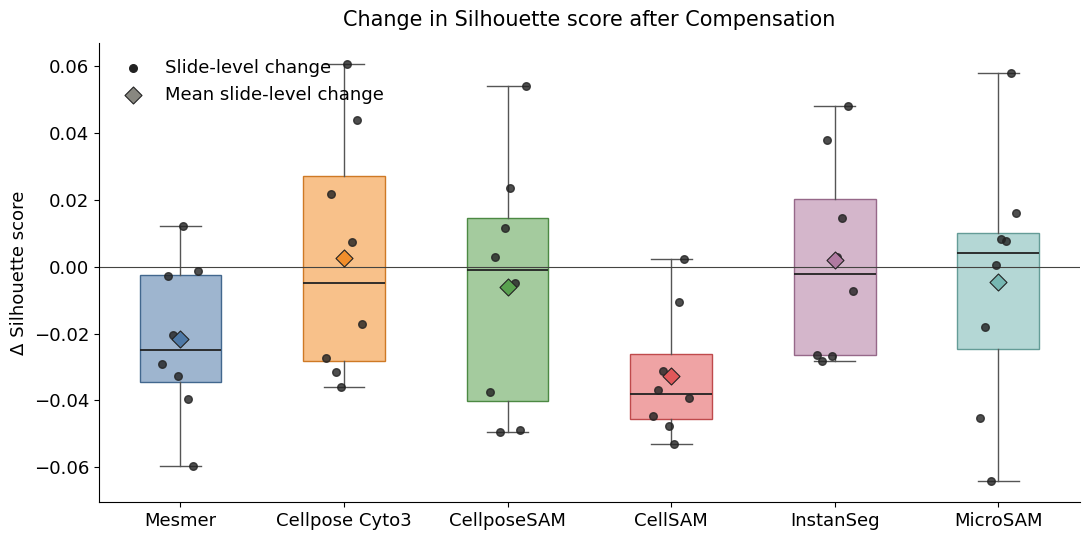

In [16]:
# ============================================================
# PANEL B: CHANGE IN SILHOUETTE SCORE
#
# Box:
#   Distribution of slide-level after-minus-before values.
#
# Circular dots:
#   Individual slide-level changes.
#
# Diamond:
#   Mean slide-level change for the method.
# ============================================================

def plot_panel_b_silhouette_change(
    silhouette_change_df,
):
    positions = np.arange(len(ALGORITHM_ORDER))

    distributions = [
        silhouette_change_df.loc[
            silhouette_change_df["method"] == method,
            "delta_silhouette",
        ]
        .dropna()
        .to_numpy()
        for method in ALGORITHM_ORDER
    ]

    fig, ax = plt.subplots(
        figsize=PANEL_B_SETTINGS["figure_size"]
    )

    box = ax.boxplot(
        distributions,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        whis=1.5,
        medianprops={"color": "#222222", "linewidth": 1.3},
        whiskerprops={"color": "#555555", "linewidth": 1},
        capprops={"color": "#555555", "linewidth": 1},
    )

    for patch, method in zip(box["boxes"], ALGORITHM_ORDER):
        base = np.array(mcolors.to_rgb(METHOD_BASE_COLORS[method]))
        light = tuple(base + (np.ones(3) - base) * 0.45)
        dark = tuple(base * 0.85)
        patch.set_facecolor(light)
        patch.set_edgecolor(dark)
        patch.set_linewidth(1)

    for method_index, method in enumerate(ALGORITHM_ORDER):
        values = (
            silhouette_change_df.loc[
                silhouette_change_df["method"] == method,
                "delta_silhouette",
            ]
            .dropna()
            .to_numpy()
        )

        if len(values):
            jitter = (
                np.array([0.0])
                if len(values) == 1
                else np.linspace(-0.11, 0.11, len(values))
            )

            ax.scatter(
                method_index + jitter,
                values,
                s=PANEL_B_SETTINGS["dot_size"],
                color=DOT_COLOR,
                alpha=PANEL_B_SETTINGS["dot_alpha"],
                zorder=4,
            )

            ax.scatter(
                method_index,
                np.mean(values),
                marker="D",
                s=PANEL_B_SETTINGS["mean_marker_size"],
                color=METHOD_BASE_COLORS[method],
                edgecolor="#222222",
                linewidth=0.8,
                zorder=5,
            )

    ax.axhline(
        0,
        color="#444441",
        linewidth=PANEL_B_SETTINGS["zero_linewidth"],
    )

    ax.scatter(
        [], [],
        marker="o",
        s=PANEL_B_SETTINGS["dot_size"],
        color=DOT_COLOR,
        label="Slide-level change",
    )
    ax.scatter(
        [], [],
        marker="D",
        s=PANEL_B_SETTINGS["mean_marker_size"],
        color="#888780",
        edgecolor="#222222",
        linewidth=0.8,
        label="Mean slide-level change",
    )

    ax.set_title(
        "Change in Silhouette score after Compensation",
        fontsize=PANEL_B_SETTINGS["title_fontsize"],
        pad=12,
    )
    ax.set_ylabel(
        "Δ Silhouette score",
        fontsize=PANEL_B_SETTINGS["axis_label_fontsize"],
    )
    ax.set_xticks(positions)
    ax.set_xticklabels(
        ALGORITHM_ORDER,
        fontsize=PANEL_B_SETTINGS["x_tick_fontsize"],
    )
    ax.tick_params(
        axis="y",
        labelsize=PANEL_B_SETTINGS["y_tick_fontsize"],
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(False)
    ax.legend(
        frameon=False,
        fontsize=PANEL_B_SETTINGS["legend_fontsize"],
    )

    plt.tight_layout()
    plt.show()


plot_panel_b_silhouette_change(
    silhouette_change_df
)


### Panel C

Change in cell-type F1 score after compensation across segmentation methods.


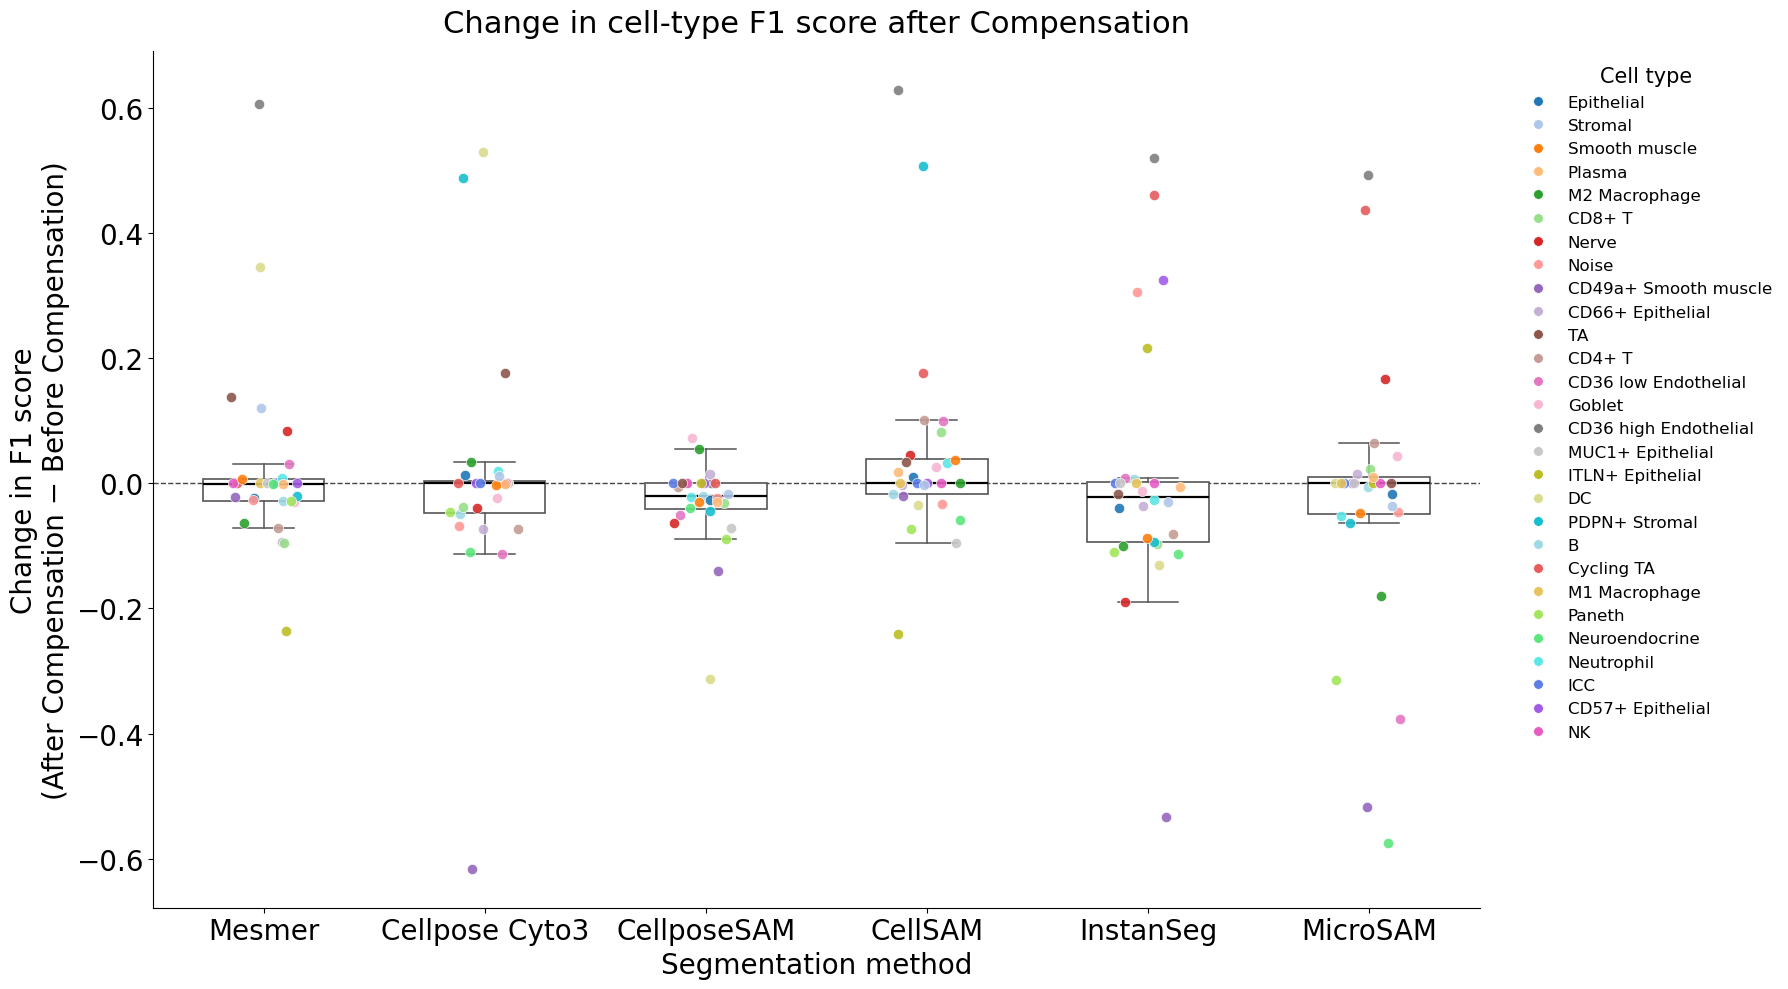

In [17]:
# ============================================================
# PANEL C: CHANGE IN CELL-TYPE F1 SCORE
# ============================================================

plot_df = celltype_f1_change_df.copy()

if ONLY_PRESENT_CELL_TYPES:
    plot_df = plot_df[
        (plot_df["true_cell_count_before"] > 0)
        | (plot_df["true_cell_count_after"] > 0)
        | (plot_df["predicted_cell_count_before"] > 0)
        | (plot_df["predicted_cell_count_after"] > 0)
    ].copy()

available_algorithms = [
    algorithm
    for algorithm in ALGORITHM_ORDER
    if algorithm in plot_df["algorithm"].unique()
]

if not available_algorithms:
    raise ValueError(
        "No segmentation methods are available to plot."
    )

present_cell_types = (
    plot_df["cell_type"].astype(str).unique()
)

unmapped_cell_types = sorted(
    set(present_cell_types) - set(CELL_TYPE_COLORS)
)

if unmapped_cell_types:
    raise ValueError(
        "These cell types do not have assigned colors: "
        f"{unmapped_cell_types}"
    )

legend_cell_types = [
    cell_type
    for cell_type in CELL_TYPE_COLORS
    if cell_type in present_cell_types
]

box_data = [
    plot_df.loc[
        plot_df["algorithm"] == algorithm,
        "delta_f1",
    ]
    .dropna()
    .to_numpy()
    for algorithm in available_algorithms
]

positions = np.arange(
    1,
    len(available_algorithms) + 1,
)

fig, ax = plt.subplots(
    figsize=PANEL_C_SETTINGS["figure_size"]
)

ax.boxplot(
    box_data,
    positions=positions,
    widths=PANEL_C_SETTINGS["box_width"],
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1.6},
    boxprops={
        "facecolor": "white",
        "edgecolor": "#555555",
        "linewidth": 1.2,
    },
    whiskerprops={"color": "#555555", "linewidth": 1.1},
    capprops={"color": "#555555", "linewidth": 1.1},
)

random_generator = np.random.default_rng(
    PANEL_C_SETTINGS["jitter_seed"]
)

for position, algorithm in zip(
    positions,
    available_algorithms,
):
    algorithm_df = plot_df[
        plot_df["algorithm"] == algorithm
    ].copy()

    jitter = random_generator.uniform(
        -PANEL_C_SETTINGS["jitter_width"],
        PANEL_C_SETTINGS["jitter_width"],
        size=len(algorithm_df),
    )

    for jitter_value, (_, row) in zip(
        jitter,
        algorithm_df.iterrows(),
    ):
        cell_type = str(row["cell_type"])

        ax.scatter(
            position + jitter_value,
            row["delta_f1"],
            color=CELL_TYPE_COLORS[cell_type],
            edgecolor="white",
            linewidth=PANEL_C_SETTINGS["dot_edge_width"],
            s=PANEL_C_SETTINGS["dot_size"],
            alpha=PANEL_C_SETTINGS["dot_alpha"],
            zorder=3,
        )

ax.axhline(
    y=0,
    color=PANEL_C_SETTINGS["zero_line_color"],
    linewidth=PANEL_C_SETTINGS["zero_line_width"],
    linestyle=PANEL_C_SETTINGS["zero_line_style"],
    zorder=1,
)

ax.set_xticks(positions)
ax.set_xticklabels(
    available_algorithms,
    fontsize=PANEL_C_FONT_SIZES["x_tick_labels"],
)
ax.tick_params(
    axis="y",
    labelsize=PANEL_C_FONT_SIZES["y_tick_labels"],
)
ax.set_xlabel(
    "Segmentation method",
    fontsize=PANEL_C_FONT_SIZES["x_axis_label"],
)
ax.set_ylabel(
    "Change in F1 score\n"
    "(After Compensation − Before Compensation)",
    fontsize=PANEL_C_FONT_SIZES["y_axis_label"],
)
ax.set_title(
    "Change in cell-type F1 score after Compensation",
    fontsize=PANEL_C_FONT_SIZES["title"],
    pad=PANEL_C_SETTINGS["title_padding"],
)

ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=CELL_TYPE_COLORS[cell_type],
        markeredgecolor="white",
        markeredgewidth=PANEL_C_SETTINGS[
            "legend_marker_edge_width"
        ],
        markersize=PANEL_C_SETTINGS["legend_marker_size"],
        label=cell_type,
    )
    for cell_type in legend_cell_types
]

ax.legend(
    handles=legend_handles,
    title="Cell type",
    bbox_to_anchor=(
        PANEL_C_SETTINGS["legend_x_position"],
        PANEL_C_SETTINGS["legend_y_position"],
    ),
    loc="upper left",
    frameon=False,
    fontsize=PANEL_C_FONT_SIZES["legend_labels"],
    title_fontsize=PANEL_C_FONT_SIZES["legend_title"],
    ncol=PANEL_C_SETTINGS["legend_columns"],
)

plt.tight_layout()
plt.show()


### Panels D–F

Volcano plots of mean slide-level ΔF1 versus Bonferroni-adjusted statistical significance. Only cell types meeting both the adjusted p-value threshold and the absolute ΔF1 threshold are labeled.


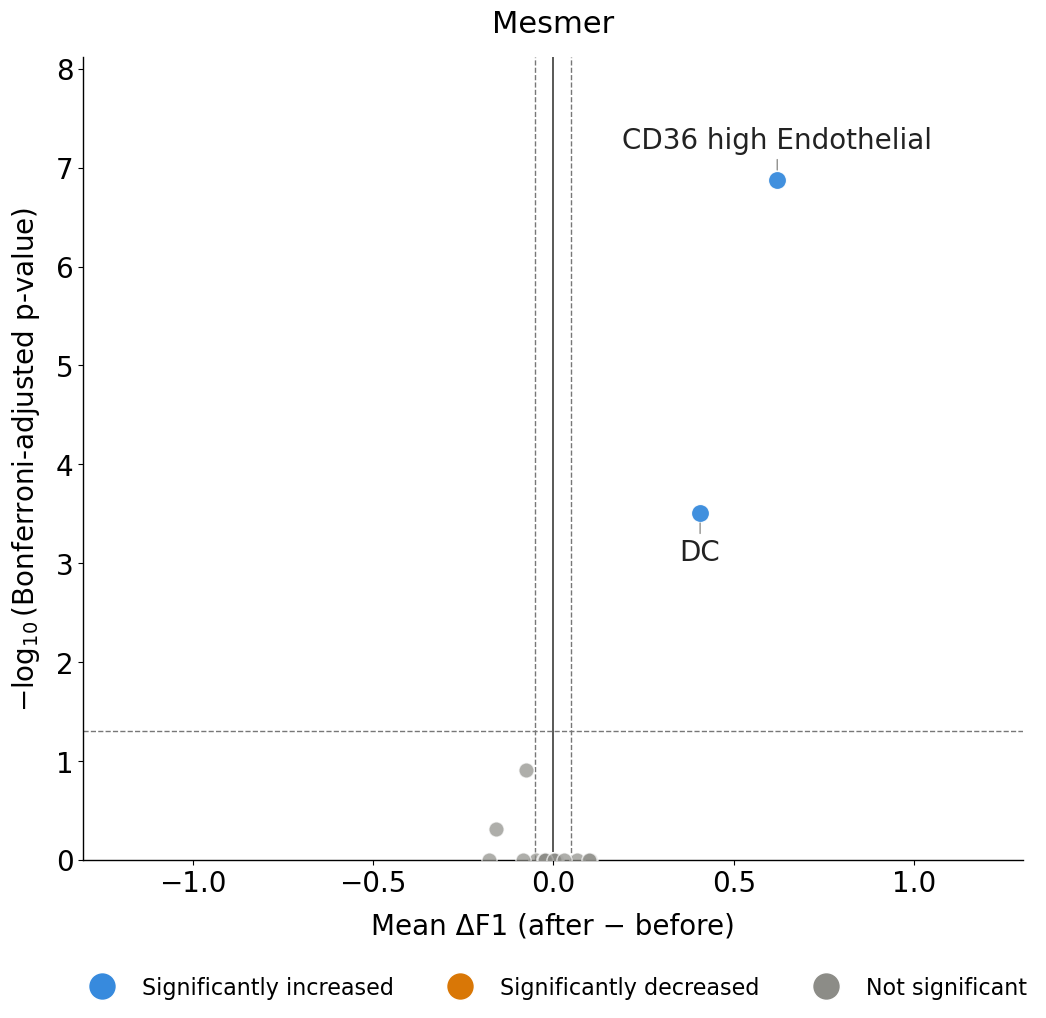

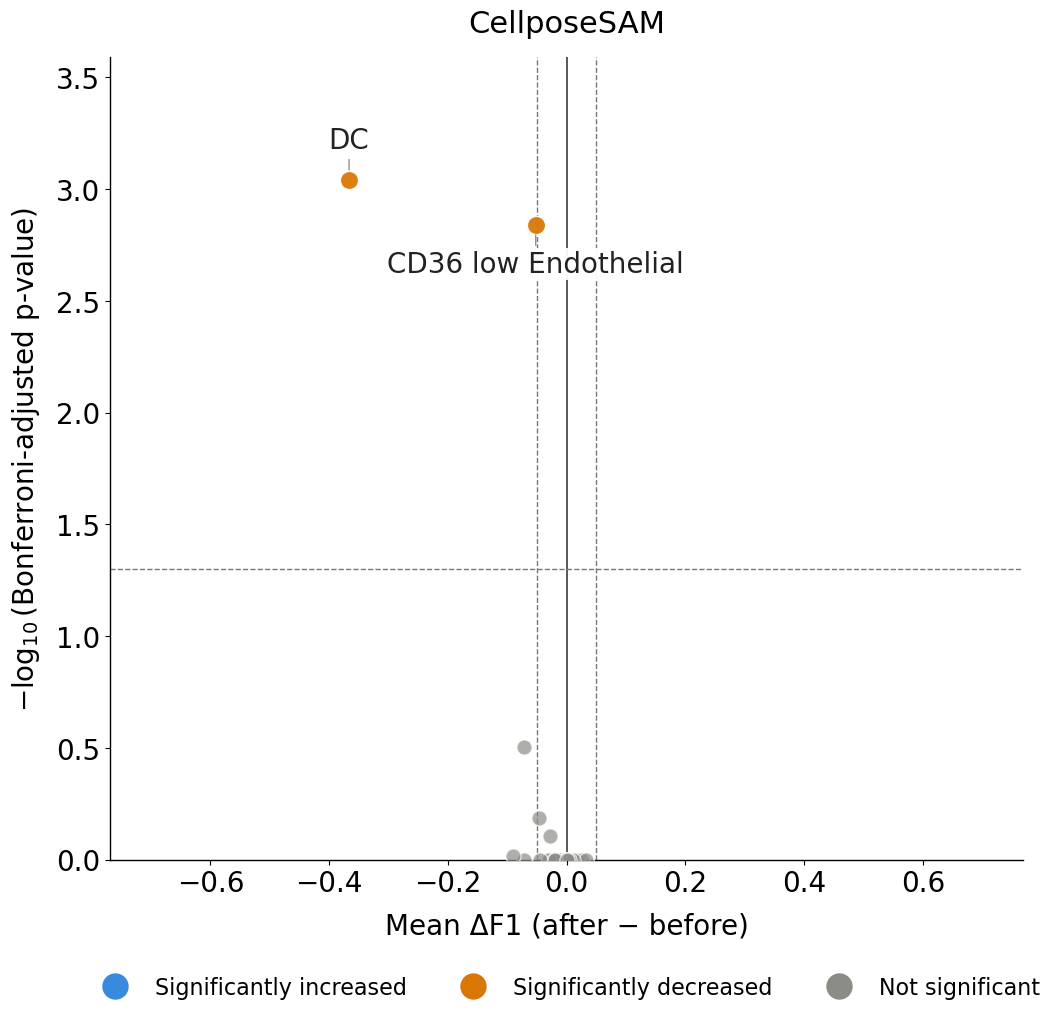

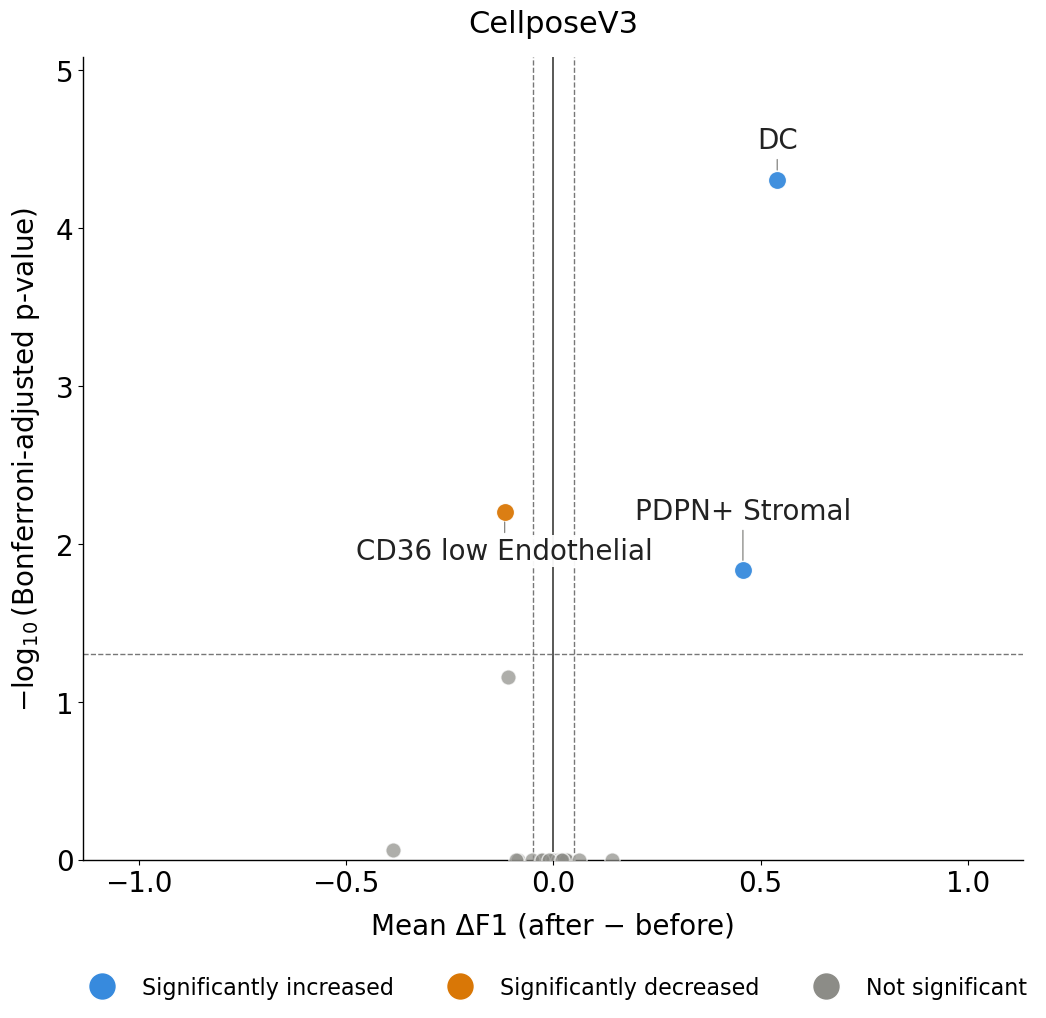

In [18]:
# ============================================================
# PANELS D-F: VOLCANO PLOTS
# ============================================================

def plot_slide_level_f1_volcanoes(
    significance_df,
    algorithms=VOLCANO_ALGORITHMS,
):
    adjusted_p_threshold = VOLCANO_SETTINGS[
        "adjusted_p_threshold"
    ]
    delta_f1_threshold = VOLCANO_SETTINGS[
        "delta_f1_threshold"
    ]
    significance_y = -np.log10(adjusted_p_threshold)

    for algorithm in algorithms:
        plot_df = significance_df[
            significance_df["algorithm"] == algorithm
        ].copy()

        plot_df = plot_df.dropna(
            subset=[
                "cell_type",
                "delta_f1",
                "adjusted_p_value",
                "minus_log10_adjusted_p",
            ]
        )

        if plot_df.empty:
            print(
                f"Skipping {algorithm}: no valid paired t-tests."
            )
            continue

        improved_mask = (
            plot_df["delta_f1"].ge(delta_f1_threshold)
            & plot_df["adjusted_p_value"].lt(
                adjusted_p_threshold
            )
        )
        worsened_mask = (
            plot_df["delta_f1"].le(-delta_f1_threshold)
            & plot_df["adjusted_p_value"].lt(
                adjusted_p_threshold
            )
        )
        significant_mask = improved_mask | worsened_mask
        nonsignificant_mask = ~significant_mask

        fig, ax = plt.subplots(
            figsize=VOLCANO_SETTINGS["figure_size"]
        )

        ax.scatter(
            plot_df.loc[nonsignificant_mask, "delta_f1"],
            plot_df.loc[
                nonsignificant_mask,
                "minus_log10_adjusted_p",
            ],
            s=VOLCANO_SETTINGS["point_size"],
            color="#8C8C87",
            alpha=0.70,
            edgecolor="white",
            linewidth=1.0,
            zorder=3,
        )

        ax.scatter(
            plot_df.loc[improved_mask, "delta_f1"],
            plot_df.loc[
                improved_mask,
                "minus_log10_adjusted_p",
            ],
            s=VOLCANO_SETTINGS["significant_point_size"],
            color="#378ADD",
            alpha=0.95,
            edgecolor="white",
            linewidth=1.1,
            zorder=4,
        )

        ax.scatter(
            plot_df.loc[worsened_mask, "delta_f1"],
            plot_df.loc[
                worsened_mask,
                "minus_log10_adjusted_p",
            ],
            s=VOLCANO_SETTINGS["significant_point_size"],
            color="#D97706",
            alpha=0.95,
            edgecolor="white",
            linewidth=1.1,
            zorder=4,
        )

        ax.axvline(
            0,
            color="#444441",
            linewidth=1.25,
            zorder=1,
        )
        ax.axvline(
            delta_f1_threshold,
            color="#777777",
            linestyle="--",
            linewidth=1.0,
            zorder=1,
        )
        ax.axvline(
            -delta_f1_threshold,
            color="#777777",
            linestyle="--",
            linewidth=1.0,
            zorder=1,
        )
        ax.axhline(
            significance_y,
            color="#777777",
            linestyle="--",
            linewidth=1.0,
            zorder=1,
        )

        maximum_absolute_data_x = max(
            float(plot_df["delta_f1"].abs().max()),
            delta_f1_threshold,
            0.05,
        )
        x_limit = (
            maximum_absolute_data_x
            * VOLCANO_SETTINGS["label_gutter_multiplier"]
        )

        maximum_y = max(
            float(plot_df["minus_log10_adjusted_p"].max()),
            significance_y,
            1.0,
        )

        ax.set_xlim(-x_limit, x_limit)
        ax.set_ylim(0, maximum_y * 1.18)

        labeled_points_df = (
            plot_df[significant_mask]
            .sort_values(
                ["minus_log10_adjusted_p", "delta_f1"],
                ascending=[False, True],
            )
            .copy()
        )

        above_counter = 0
        below_counter = 0

        for label_index, (_, row) in enumerate(
            labeled_points_df.iterrows()
        ):
            point_x = float(row["delta_f1"])
            point_y = float(row["minus_log10_adjusted_p"])
            place_above = label_index % 2 == 0

            if place_above:
                vertical_offset = 18 + 14 * above_counter
                vertical_alignment = "bottom"
                above_counter += 1
            else:
                vertical_offset = -(18 + 14 * below_counter)
                vertical_alignment = "top"
                below_counter += 1

            normalized_x = point_x / x_limit if x_limit > 0 else 0.0

            if normalized_x >= 0.65:
                horizontal_alignment = "right"
                horizontal_offset = 8
            elif normalized_x <= -0.65:
                horizontal_alignment = "left"
                horizontal_offset = -8
            else:
                horizontal_alignment = "center"
                horizontal_offset = 0

            ax.annotate(
                str(row["cell_type"]),
                xy=(point_x, point_y),
                xytext=(horizontal_offset, vertical_offset),
                textcoords="offset points",
                ha=horizontal_alignment,
                va=vertical_alignment,
                fontsize=VOLCANO_SETTINGS[
                    "celltype_label_fontsize"
                ],
                color="#222222",
                annotation_clip=True,
                clip_on=True,
                zorder=6,
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.94,
                    "pad": 1.5,
                },
                arrowprops={
                    "arrowstyle": "-",
                    "color": "#6F6F6B",
                    "linewidth": 0.85,
                    "alpha": 0.90,
                    "shrinkA": 2,
                    "shrinkB": 7,
                },
            )

        ax.set_title(
            VOLCANO_TITLES.get(algorithm, algorithm),
            fontsize=VOLCANO_SETTINGS["title_fontsize"],
            pad=18,
            fontweight="normal",
        )
        ax.set_xlabel(
            "Mean ΔF1 (after − before)",
            fontsize=VOLCANO_SETTINGS["axis_label_fontsize"],
            labelpad=10,
        )
        ax.set_ylabel(
            r"$-\log_{10}$"
            "(Bonferroni-adjusted p-value)",
            fontsize=VOLCANO_SETTINGS["axis_label_fontsize"],
            labelpad=10,
        )
        ax.tick_params(
            axis="both",
            labelsize=VOLCANO_SETTINGS["tick_fontsize"],
        )

        ax.grid(False)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines["left"].set_linewidth(1.0)
        ax.spines["bottom"].set_linewidth(1.0)

        legend_handles = [
            Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                markerfacecolor="#378ADD",
                markeredgecolor="white",
                markeredgewidth=1.0,
                markersize=VOLCANO_SETTINGS[
                    "legend_marker_size"
                ],
                label="Significantly increased",
            ),
            Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                markerfacecolor="#D97706",
                markeredgecolor="white",
                markeredgewidth=1.0,
                markersize=VOLCANO_SETTINGS[
                    "legend_marker_size"
                ],
                label="Significantly decreased",
            ),
            Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                markerfacecolor="#8C8C87",
                markeredgecolor="white",
                markeredgewidth=1.0,
                markersize=VOLCANO_SETTINGS[
                    "legend_marker_size"
                ],
                label="Not significant",
            ),
        ]

        ax.legend(
            handles=legend_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.12),
            ncol=3,
            frameon=False,
            fontsize=VOLCANO_SETTINGS["legend_fontsize"],
        )

        plt.tight_layout(rect=[0, 0.06, 1, 1])
        plt.show()


plot_slide_level_f1_volcanoes(
    significance_df=celltype_f1_significance_df,
    algorithms=VOLCANO_ALGORITHMS,
)
